# Model Development — Logistic Regression Scorecard

## Objective
Train a Logistic Regression model on WoE-transformed features and convert the model output into a points-based credit scorecard.

## Why Logistic Regression?
- Only model type that can be mathematically converted to a scorecard
- Fully interpretable — each variable's contribution to the score is transparent and auditable
- Basel II/III compliant — regulators require explainable models for retail credit risk
- Industry standard — used by FICO, CIBIL, Experian, and all major banks

## Scorecard Scaling Parameters
- Base score: 600 (score assigned at base odds)
- Base odds: 50:1 (non-default:default ratio at base score)
- PDO: 20 (points to double the odds — standard industry setting)

In [2]:
# ============================================================
# Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# Load WoE transformed datasets
train = pd.read_csv('../data/train_woe.csv', index_col=0)
test  = pd.read_csv('../data/test_woe.csv',  index_col=0)

# Separate features and target
feature_cols = [col for col in train.columns if col != 'target']

X_train = train[feature_cols]
y_train = train['target']

X_test  = test[feature_cols]
y_test  = test['target']

print("Data loaded successfully")
print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"Features:      {feature_cols}")
print(f"\nDefault rate — train: {y_train.mean()*100:.2f}%")
print(f"Default rate — test:  {y_test.mean()*100:.2f}%")

Data loaded successfully
Training set:  (104999, 7)
Test set:      (45000, 7)
Features:      ['RevolvingUtilizationOfUnsecuredLines_WoE', 'NumberOfTime30-59DaysPastDueNotWorse_WoE', 'age_WoE', 'DebtRatio_WoE', 'MonthlyIncome_WoE', 'NumberOfOpenCreditLinesAndLoans_WoE', 'NumberOfDependents_WoE']

Default rate — train: 6.68%
Default rate — test:  6.68%


## Model Training

### Key parameters:
- **class_weight='balanced'** — automatically adjusts weights inversely proportional to class frequency. Gives 13.9x more weight to defaulters than non-defaulters, compensating for the 93/7 imbalance.
  
- **C=0.5** — regularisation strength. Lower C = stronger regularisation = simpler model. Prevents the model from overfitting to noise in weak variables like NumberOfDependents.

- **max_iter=1000** — maximum iterations for the solver to converge.

In [3]:
# ============================================================
# Logistic Regression Model
# ============================================================

# class_weight='balanced' addresses our class imbalance problem
# C=0.5 is regularisation — prevents overfitting
# We discussed both of these in Week 2
lr_model = LogisticRegression(
    class_weight='balanced',  # addresses 93/7 imbalance
    C=0.5,                    # L2 regularisation
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

print("Model trained successfully")
print(f"\nModel coefficients:")
print(f"{'Feature':<45} {'Coefficient':>12}")
print("-" * 60)

for feat, coef in zip(feature_cols, lr_model.coef_[0]):
    print(f"{feat:<45} {coef:>12.4f}")

print(f"\nIntercept: {lr_model.intercept_[0]:.4f}")

Model trained successfully

Model coefficients:
Feature                                        Coefficient
------------------------------------------------------------
RevolvingUtilizationOfUnsecuredLines_WoE            0.8382
NumberOfTime30-59DaysPastDueNotWorse_WoE            0.8264
age_WoE                                             0.4886
DebtRatio_WoE                                       0.7179
MonthlyIncome_WoE                                   0.3729
NumberOfOpenCreditLinesAndLoans_WoE                 0.3332
NumberOfDependents_WoE                              0.2067

Intercept: -0.0068


## Scorecard Scaling

We convert logistic regression output into a points-based scorecard using the industry-standard PDO (Points to Double the Odds) method.

### Scaling parameters:
- **Base score: 600** — industry convention. A borrower at 50:1 odds (50 non-defaults per default) receives a score of 600.
- **Base odds: 50:1** — represents a moderate-risk borrower.
- **PDO: 20** — every 20-point increase in score doubles the odds of being a non-defaulter. Standard industry setting.

### Scorecard formula:
Score = Offset + Factor × (−log odds)
- Factor = PDO / ln(2) = 28.85
- Offset = Base score − Factor × ln(Base odds) = 487.12

Each variable contributes a partial score based on its WoE bin.
Final score = sum of all partial scores.
Higher score = lower default risk.

In [4]:
# ============================================================
# Scorecard Scaling
# ============================================================

# Industry standard scaling parameters
BASE_SCORE = 600   # score at base odds
BASE_ODDS  = 50    # 50 non-defaults per 1 default at base score
PDO        = 20    # points to double the odds

# Derived scaling factors
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

print(f"Scaling parameters:")
print(f"  Base score : {BASE_SCORE}")
print(f"  Base odds  : {BASE_ODDS}:1")
print(f"  PDO        : {PDO}")
print(f"  Factor     : {factor:.4f}")
print(f"  Offset     : {offset:.4f}")

# ---- Build scorecard table ----
# Each variable contributes points based on:
# Points = -(coefficient × WoE + intercept/n_vars) × factor
# We split the intercept equally across all variables

n_vars     = len(feature_cols)
intercept  = lr_model.intercept_[0]
coefs      = dict(zip(feature_cols, lr_model.coef_[0]))

scorecard_rows = []

for col in feature_cols:
    woe_table = pd.read_csv('../data/train_woe.csv', index_col=0)
    
    # Get unique WoE values for this variable
    unique_woes = train[col].unique()
    
    for woe_val in sorted(unique_woes):
        # Points formula
        points = -(coefs[col] * woe_val + intercept/n_vars) * factor + offset/n_vars
        
        scorecard_rows.append({
            'Variable'  : col.replace('_WoE', ''),
            'WoE'       : round(woe_val, 4),
            'Points'    : round(points, 1)
        })

scorecard_df = pd.DataFrame(scorecard_rows)

print(f"\n=== Scorecard Table ===")
print(scorecard_df.to_string(index=False))

Scaling parameters:
  Base score : 600
  Base odds  : 50:1
  PDO        : 20
  Factor     : 28.8539
  Offset     : 487.1229

=== Scorecard Table ===
                            Variable     WoE  Points
RevolvingUtilizationOfUnsecuredLines -1.6183   108.8
RevolvingUtilizationOfUnsecuredLines -1.5711   107.6
RevolvingUtilizationOfUnsecuredLines -1.2604   100.1
RevolvingUtilizationOfUnsecuredLines -1.1064    96.4
RevolvingUtilizationOfUnsecuredLines -1.0410    94.8
RevolvingUtilizationOfUnsecuredLines -0.7488    87.7
RevolvingUtilizationOfUnsecuredLines -0.2591    75.9
RevolvingUtilizationOfUnsecuredLines  0.3261    61.7
RevolvingUtilizationOfUnsecuredLines  1.0117    45.1
RevolvingUtilizationOfUnsecuredLines  1.4392    34.8
NumberOfTime30-59DaysPastDueNotWorse -0.2385    75.3
NumberOfTime30-59DaysPastDueNotWorse  1.8531    25.4
                                 age -1.1557    85.9
                                 age -0.9375    82.8
                                 age -0.4883    76.5
   

In [5]:
# ============================================================
# Calculate Credit Scores
# ============================================================

def calculate_score(X_woe, coefs, intercept, factor, offset, n_vars):
    """
    Convert WoE features into a final credit score for each borrower.
    Score = Offset + Factor × log(odds)
    """
    # Log odds = intercept + sum(coefficient × WoE) for each variable
    log_odds = intercept + X_woe.values @ lr_model.coef_[0]
    
    # Convert to score
    scores = offset + factor * (-log_odds)
    
    # Clip to realistic range
    scores = np.clip(scores, 300, 850)
    
    return scores

# Calculate scores for train and test sets
train_scores = calculate_score(X_train, coefs, intercept, factor, offset, n_vars)
test_scores  = calculate_score(X_test,  coefs, intercept, factor, offset, n_vars)

print("=== Score Distribution ===")
print(f"\nTraining set:")
print(f"  Mean score  : {train_scores.mean():.1f}")
print(f"  Median score: {np.median(train_scores):.1f}")
print(f"  Min score   : {train_scores.min():.1f}")
print(f"  Max score   : {train_scores.max():.1f}")
print(f"  Std dev     : {train_scores.std():.1f}")

print(f"\nTest set:")
print(f"  Mean score  : {test_scores.mean():.1f}")
print(f"  Median score: {np.median(test_scores):.1f}")
print(f"  Min score   : {test_scores.min():.1f}")
print(f"  Max score   : {test_scores.max():.1f}")
print(f"  Std dev     : {test_scores.std():.1f}")

# Score by default status
print(f"\n=== Score by Default Status (Test Set) ===")
test_df = pd.DataFrame({
    'score' : test_scores,
    'target': y_test.values
})

print(f"  Non-defaulters avg score: {test_df[test_df['target']==0]['score'].mean():.1f}")
print(f"  Defaulters avg score    : {test_df[test_df['target']==1]['score'].mean():.1f}")
print(f"  Score gap               : {test_df[test_df['target']==0]['score'].mean() - test_df[test_df['target']==1]['score'].mean():.1f} points")

=== Score Distribution ===

Training set:
  Mean score  : 504.9
  Median score: 513.9
  Min score   : 377.9
  Max score   : 559.9
  Std dev     : 34.1

Test set:
  Mean score  : 505.1
  Median score: 513.9
  Min score   : 377.9
  Max score   : 559.9
  Std dev     : 33.9

=== Score by Default Status (Test Set) ===
  Non-defaulters avg score: 508.0
  Defaulters avg score    : 464.2
  Score gap               : 43.9 points


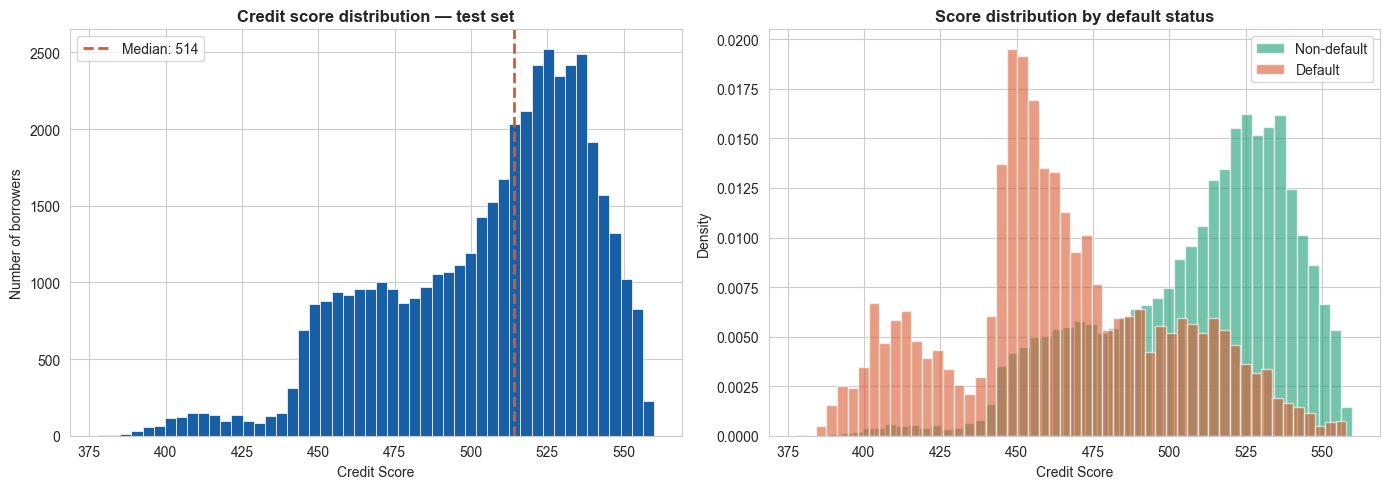

Chart saved to reports folder


In [6]:
# ============================================================
# Score Distribution Chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Overall score distribution
axes[0].hist(test_scores, bins=50, color='#185FA5', 
             edgecolor='white', linewidth=0.5)
axes[0].set_title('Credit score distribution — test set', fontweight='bold')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Number of borrowers')
axes[0].axvline(np.median(test_scores), color='#D85A30', 
                linestyle='--', linewidth=2,
                label=f'Median: {np.median(test_scores):.0f}')
axes[0].legend()

# Chart 2 — Score by default status
test_df_0 = test_df[test_df['target']==0]['score']
test_df_1 = test_df[test_df['target']==1]['score']

axes[1].hist(test_df_0, bins=50, alpha=0.6, color='#1D9E75', 
             edgecolor='white', label='Non-default', density=True)
axes[1].hist(test_df_1, bins=50, alpha=0.6, color='#D85A30', 
             edgecolor='white', label='Default', density=True)
axes[1].set_title('Score distribution by default status', fontweight='bold')
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/07_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports folder")

### Finding 7 — Score Distribution Results

- Score range: 378 to 560
- Median score: 514
- Non-defaulters average score: 508
- Defaulters average score: 464
- Score gap: 43.9 points

The 44-point separation between defaulters and non-defaulters confirms meaningful discriminatory power. The score distribution chart shows clear rightward shift of non-defaulter scores relative to defaulter scores — visual confirmation that the scorecard is separating risk as intended.

Score range is narrower than commercial bureau scores (300-900) due to limited variable set compared to full credit bureau data. This is expected and documented as a model limitation.

In [7]:
# ============================================================
# Save Scores
# ============================================================

# Save scores to data folder
train_output = pd.DataFrame({
    'score' : train_scores,
    'target': y_train.values,
    'predicted_proba': lr_model.predict_proba(X_train)[:, 1]
}, index=X_train.index)

test_output = pd.DataFrame({
    'score' : test_scores,
    'target': y_test.values,
    'predicted_proba': lr_model.predict_proba(X_test)[:, 1]
}, index=X_test.index)

train_output.to_csv('../data/train_scores.csv')
test_output.to_csv('../data/test_scores.csv')

# Save scorecard table
scorecard_df.to_csv('../data/scorecard_table.csv', index=False)

print("Saved:")
print("  data/train_scores.csv")
print("  data/test_scores.csv")
print("  data/scorecard_table.csv")
print(f"\nScorecard has {len(scorecard_df)} rows across {len(feature_cols)} variables")

Saved:
  data/train_scores.csv
  data/test_scores.csv
  data/scorecard_table.csv

Scorecard has 55 rows across 7 variables
